In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
import warnings

In [155]:
warnings.filterwarnings("ignore")

In [156]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable


In [157]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("desolution01/messy-employee-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\91801\.cache\kagglehub\datasets\desolution01\messy-employee-dataset\versions\1


In [158]:
#Checking the files inside 
import os
print(os.listdir(path))

['Messy_Employee_dataset.csv']


In [159]:
file_path = os.path.join(path, 'Messy_Employee_dataset.csv')
df = pd.read_csv(file_path)
df.head(10)

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False
5,EMP1005,Alice,Garcia,40.0,Sales-Texas,Inactive,6/10/2020,88642.84,alice.garcia@example.com,-5409003485,Good,False
6,EMP1006,Frank,Jones,NaN,Admin-Nevada,Active,4/3/2020,96288.43,frank.jones@example.com,-4518376063,Good,False
7,EMP1007,Bob,Jones,30.0,Cloud Tech-Florida,Inactive,7/17/2022,94497.91,bob.jones@example.com,-4134327559,Average,True
8,EMP1008,Frank,Davis,35.0,Admin-Nevada,Inactive,12/8/2023,115565.82,frank.davis@example.com,-4177656123,Excellent,True
9,EMP1009,Charlie,Johnson,NaN,DevOps-New York,Active,8/4/2022,76561.88,charlie.johnson@example.com,-8156985699,Excellent,True


In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   object 
 1   First_Name         1020 non-null   object 
 2   Last_Name          1020 non-null   object 
 3   Age                809 non-null    float64
 4   Department_Region  1020 non-null   object 
 5   Status             1020 non-null   object 
 6   Join_Date          1020 non-null   object 
 7   Salary             996 non-null    float64
 8   Email              1020 non-null   object 
 9   Phone              1020 non-null   int64  
 10  Performance_Score  1020 non-null   object 
 11  Remote_Work        1020 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(8)
memory usage: 88.8+ KB


In [161]:
print(f"The Number of rows = {df.shape[0]} & The Number of columns = {df.shape[1]}")

The Number of rows = 1020 & The Number of columns = 12


In [162]:
df.describe(include="all")

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
count,1020,1020,1020,809.000000,1020,1020,1020,996.000000,1020,1.020000e+03,1020,1020
unique,1020,8,8,NaN,36,3,760,NaN,64,NaN,4,2
top,EMP1000,Frank,Brown,NaN,HR-Florida,Pending,6/10/2024,NaN,grace.brown@example.com,NaN,Good,True
freq,1,142,148,NaN,41,356,5,NaN,27,NaN,270,513
mean,NaN,NaN,NaN,32.484549,NaN,NaN,NaN,85155.056396,NaN,-4.942253e+09,NaN,NaN
std,NaN,NaN,NaN,5.656860,NaN,NaN,NaN,19873.727918,NaN,2.817326e+09,NaN,NaN
min,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,50047.320000,NaN,-9.994973e+09,NaN,NaN
25%,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,68392.487500,NaN,-7.341992e+09,NaN,NaN
50%,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,85547.870000,NaN,-4.943997e+09,NaN,NaN
75%,NaN,NaN,NaN,40.000000,NaN,NaN,NaN,100974.027500,NaN,-2.520391e+09,NaN,NaN


In [163]:
df.isnull().sum()

Employee_ID            0
First_Name             0
Last_Name              0
Age                  211
Department_Region      0
Status                 0
Join_Date              0
Salary                24
Email                  0
Phone                  0
Performance_Score      0
Remote_Work            0
dtype: int64

In [164]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')

In [165]:
df.columns

Index(['employee_id', 'first_name', 'last_name', 'age', 'department_region',
       'status', 'join_date', 'salary', 'email', 'phone', 'performance_score',
       'remote_work'],
      dtype='object')

In [166]:
df['age'].value_counts()

age
40.0    210
25.0    206
30.0    205
35.0    188
Name: count, dtype: int64

In [167]:
df['age'].median()

30.0

In [168]:
df['age'] = df['age'].fillna(df['age'].median())

In [169]:
df.isnull().sum()

employee_id           0
first_name            0
last_name             0
age                   0
department_region     0
status                0
join_date             0
salary               24
email                 0
phone                 0
performance_score     0
remote_work           0
dtype: int64

In [170]:
df['age'].value_counts()

age
30.0    416
40.0    210
25.0    206
35.0    188
Name: count, dtype: int64

In [171]:
df['age']=df['age'].astype(int)

In [172]:
df['age'].value_counts()

age
30    416
40    210
25    206
35    188
Name: count, dtype: int64

In [173]:
labels = ['Young-Adult','Adult','Middle-Aged','Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels=labels[:3], duplicates='drop')

In [174]:
df[['age','age_group']].head(10)

,age,age_group
0,25,Young-Adult
1,30,Young-Adult
2,30,Young-Adult
3,25,Young-Adult
4,25,Young-Adult
5,40,Middle-Aged
6,30,Young-Adult
7,30,Young-Adult
8,35,Adult
9,30,Young-Adult


In [175]:
# Making 'Departmemnt' and 'Region' into two different columns 
df[['department', 'region']] = df['department_region'].str.split('-', expand=True)
df.drop(columns='department_region', inplace=True)

In [176]:
df[['department','region']].head(10)

,department,region
0,DevOps,California
1,Finance,Texas
2,Admin,Nevada
3,Admin,Nevada
4,Cloud Tech,Florida
5,Sales,Texas
6,Admin,Nevada
7,Cloud Tech,Florida
8,Admin,Nevada
9,DevOps,New York


In [177]:
df.head(5)

,employee_id,first_name,last_name,age,status,join_date,salary,email,phone,performance_score,remote_work,age_group,department,region
0,EMP1000,Bob,Davis,25,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True,Young-Adult,DevOps,California
1,EMP1001,Bob,Brown,30,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True,Young-Adult,Finance,Texas
2,EMP1002,Alice,Jones,30,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True,Young-Adult,Admin,Nevada
3,EMP1003,Eva,Davis,25,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True,Young-Adult,Admin,Nevada
4,EMP1004,Frank,Williams,25,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False,Young-Adult,Cloud Tech,Florida


In [178]:
df['employee_name'] = df['first_name'] + ' ' + df['last_name']

In [179]:
df.drop(columns=['first_name', 'last_name'], inplace=True)

In [180]:
df.head(2)

,employee_id,age,status,join_date,salary,email,phone,performance_score,remote_work,age_group,department,region,employee_name
0,EMP1000,25,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True,Young-Adult,DevOps,California,Bob Davis
1,EMP1001,30,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True,Young-Adult,Finance,Texas,Bob Brown


In [181]:
# Removing the column 'employee_name' temporarily to place it at the 2nd position
employee_name = df.pop('employee_name')
df.insert(1, 'employee_name', employee_name)

In [182]:
df.head(2)

,employee_id,employee_name,age,status,join_date,salary,email,phone,performance_score,remote_work,age_group,department,region
0,EMP1000,Bob Davis,25,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True,Young-Adult,DevOps,California
1,EMP1001,Bob Brown,30,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True,Young-Adult,Finance,Texas


In [183]:
df.isnull().sum()

employee_id           0
employee_name         0
age                   0
status                0
join_date             0
salary               24
email                 0
phone                 0
performance_score     0
remote_work           0
age_group             0
department            0
region                0
dtype: int64

In [184]:
df['salary'] = df['salary'].fillna(
    df.groupby(['department','region'])['salary'].transform('median')
)

In [185]:
df.head(5)

,employee_id,employee_name,age,status,join_date,salary,email,phone,performance_score,remote_work,age_group,department,region
0,EMP1000,Bob Davis,25,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True,Young-Adult,DevOps,California
1,EMP1001,Bob Brown,30,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True,Young-Adult,Finance,Texas
2,EMP1002,Alice Jones,30,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True,Young-Adult,Admin,Nevada
3,EMP1003,Eva Davis,25,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True,Young-Adult,Admin,Nevada
4,EMP1004,Frank Williams,25,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False,Young-Adult,Cloud Tech,Florida


In [186]:
df.isnull().sum()

employee_id          0
employee_name        0
age                  0
status               0
join_date            0
salary               0
email                0
phone                0
performance_score    0
remote_work          0
age_group            0
department           0
region               0
dtype: int64

In [187]:
df['salary']=df['salary'].round().astype(int)

In [188]:
df['salary']

0        59768
1        65305
2        88146
3        69451
4       109325
         ...  
1015     85970
1016    100215
1017    114587
1018     71319
1019     77764
Name: salary, Length: 1020, dtype: int32

In [189]:
df = df.drop(['email', 'phone'], axis=1)

In [190]:
df.columns

Index(['employee_id', 'employee_name', 'age', 'status', 'join_date', 'salary',
       'performance_score', 'remote_work', 'age_group', 'department',
       'region'],
      dtype='object')

In [191]:
# Removing the column 'age_group' temporarily to place it at the 4th position
employee_name = df.pop('age_group')
df.insert(3, 'age_group', employee_name)

In [192]:
df.columns

Index(['employee_id', 'employee_name', 'age', 'age_group', 'status',
       'join_date', 'salary', 'performance_score', 'remote_work', 'department',
       'region'],
      dtype='object')

# Creating the table and loading the clean Dataset into the Database

In [193]:
!pip install psycopg2-binary sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [194]:
from sqlalchemy import create_engine
username = "postgres"
passowrd = "030822"
host = "localhost"
port = "5432"
database = "messy_employees"

engine = create_engine(f"postgresql+psycopg2://{username}:{passowrd}@{host}:{port}/{database}")

In [195]:
table_name = "employee_details"
df.to_sql(table_name, engine, if_exists="replace", index=False)
print(f"Data has been successfully loaded into the table '{table_name}' in database '{database}'.")

Data has been successfully loaded into the table 'employee_details' in database 'messy_employees'.


# Visualizing the insights found

# 1.Performance based on Department

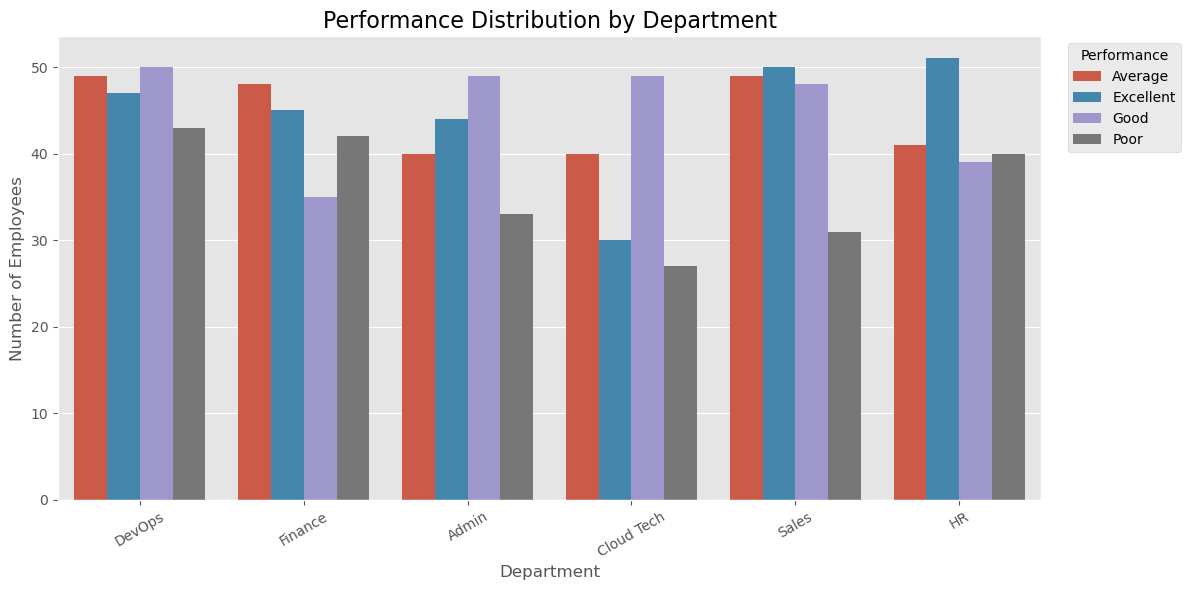

In [196]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='department',
    hue='performance_score'
)

plt.title("Performance Distribution by Department", fontsize=16)
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=30)

plt.legend(
    title="Performance",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# 2. Performance based on Region

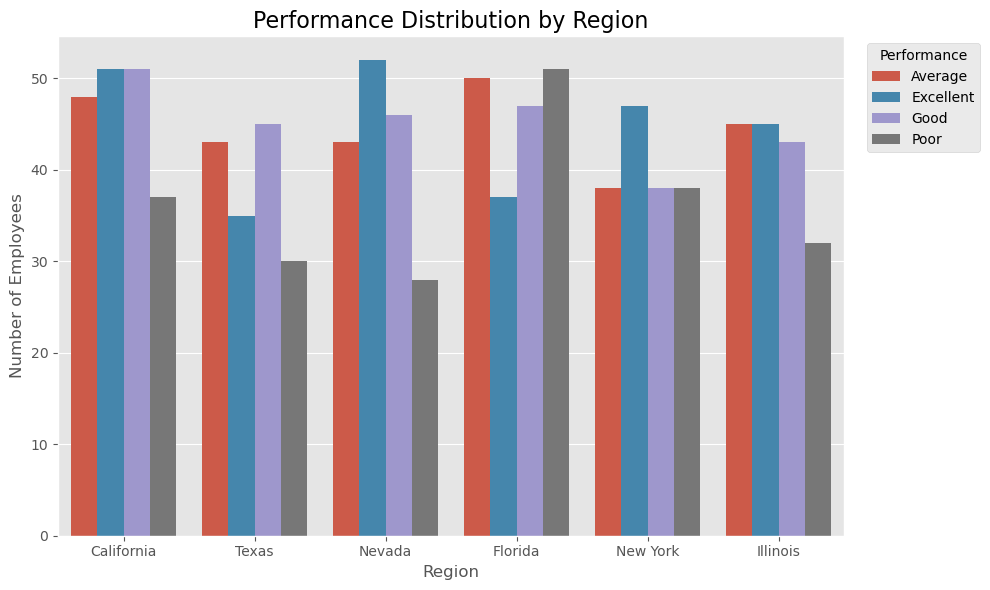

In [197]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='region',
    hue='performance_score'
)

plt.title("Performance Distribution by Region", fontsize=16)
plt.xlabel("Region")
plt.ylabel("Number of Employees")

plt.legend(
    title="Performance",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# 3. Performance based on Department & Region

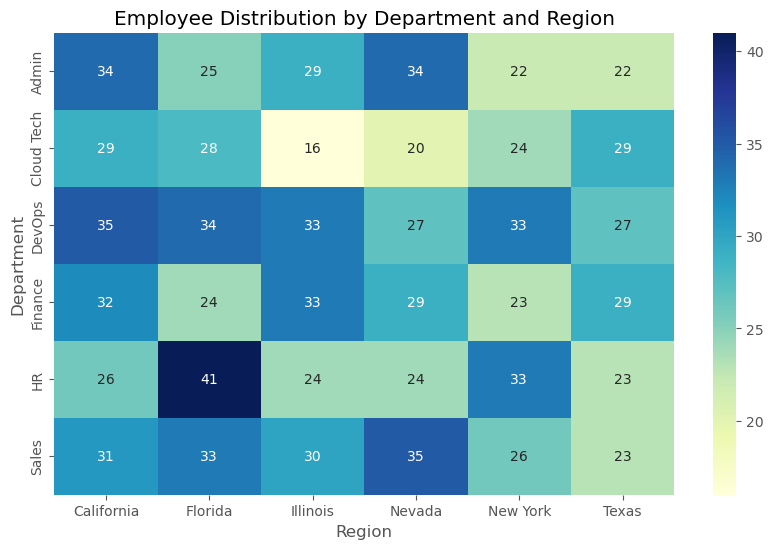

In [198]:
performance_heatmap = pd.crosstab(
    df['department'],
    df['region']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    performance_heatmap,
    annot=True,
    cmap='YlGnBu',
    fmt='d'
)

plt.title("Employee Distribution by Department and Region")
plt.xlabel("Region")
plt.ylabel("Department")

plt.show()

In [199]:
df['performance_score'].unique()

array(['Average', 'Excellent', 'Good', 'Poor'], dtype=object)

In [200]:
performance_map = {
    "Poor": 1,
    "Average": 2,
    "Good": 3,
    "Excellent": 4
}

df["performance_score"] = df["performance_score"].map(performance_map)

# Performance by Age Group

In [201]:
#Calculating the Average Performance Score

performance_by_age = (
    df.groupby("age_group")["performance_score"]
      .mean()
      .reset_index()
      .sort_values(by="performance_score", ascending=False)
)

performance_by_age

,age_group,performance_score
0,Young-Adult,2.602894
2,Middle-Aged,2.538095
1,Adult,2.531915


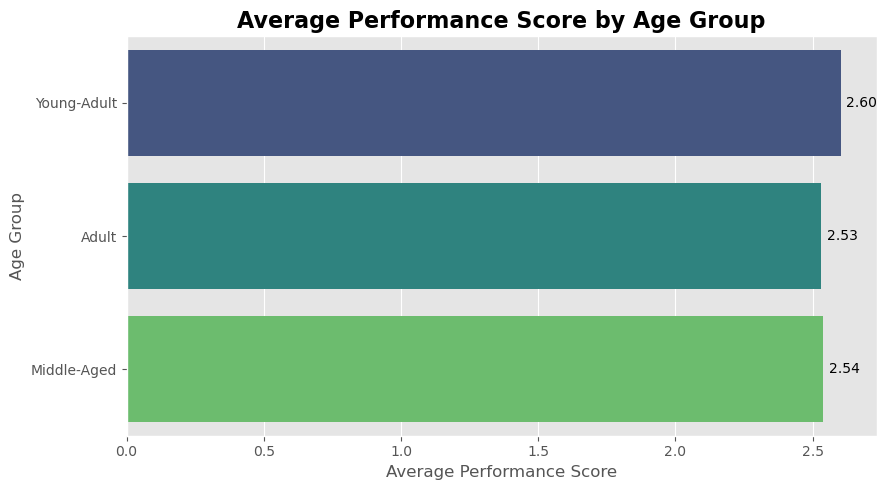

In [202]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=performance_by_age,
    x="performance_score",
    y="age_group",
    palette="viridis"
)

# Add value labels
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f", padding=4)

plt.title("Average Performance Score by Age Group", fontsize=16, weight="bold")
plt.xlabel("Average Performance Score")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

# Remote/Onsite employees based on Departmnet & Region

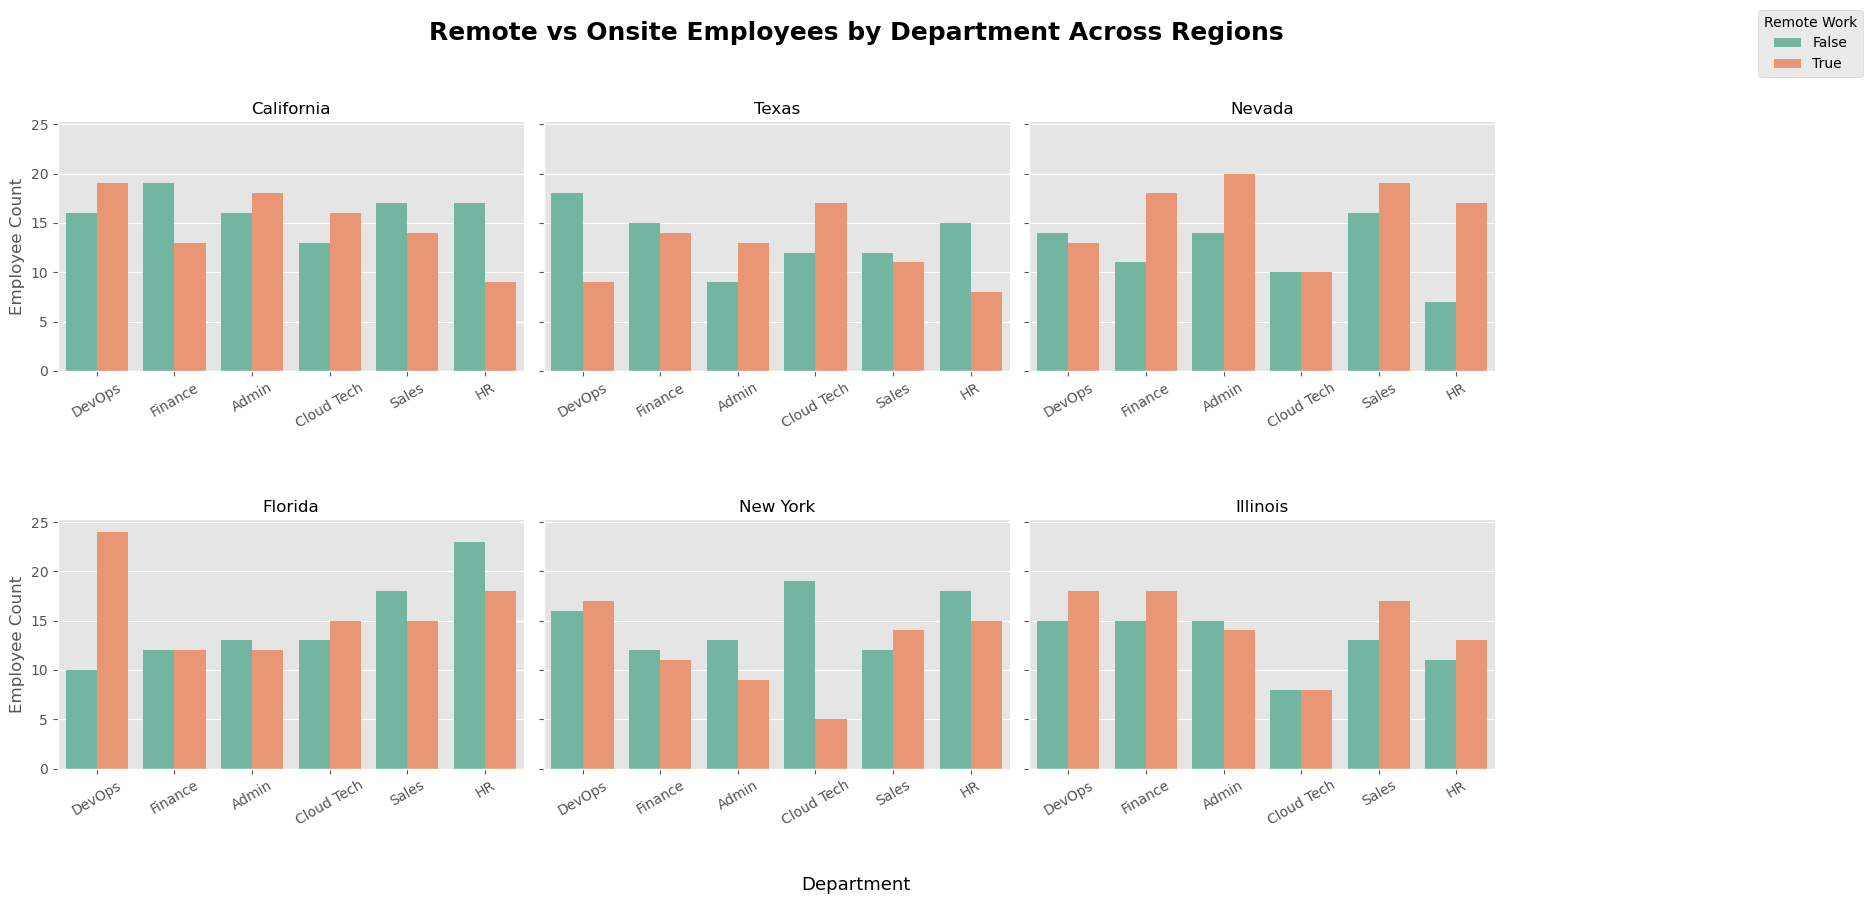

In [203]:
g = sns.catplot(
    data=df,
    x="department",
    hue="remote_work",
    col="region",
    kind="count",
    col_wrap=3,
    height=4.5,
    aspect=1.2,
    palette="Set2",
    sharex=True
)

# Region titles
g.set_titles("{col_name}")

# Remove repeated x-axis labels
g.set_xlabels("")
g.set_ylabels("Employee Count")

# Show department names in ALL subplots
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=30)
    ax.xaxis.set_tick_params(labelbottom=True)
    for label in ax.get_xticklabels():
        label.set_visible(True)

# Move legend outside
sns.move_legend(
    g,
    "upper left",
    bbox_to_anchor=(1.02, 1),
    title="Remote Work",
    frameon=True
)

# Main title
g.fig.suptitle(
    "Remote vs Onsite Employees by Department Across Regions",
    fontsize=18,
    fontweight="bold"
)

# Common X-axis label
g.fig.supxlabel("Department", fontsize=13)

# Layout
g.fig.tight_layout(rect=[0, 0.03, 0.88, 0.95])

# Increase the gap between the two rows
g.fig.subplots_adjust(hspace=0.6)

plt.show()

# Average Salary v/s Department & Location

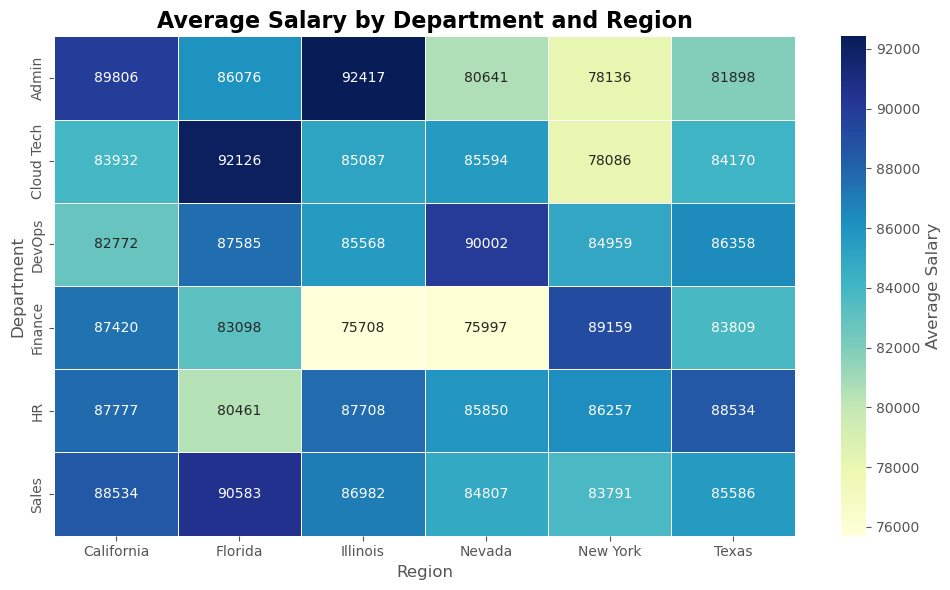

In [204]:
# Create pivot table
salary_heatmap = df.pivot_table(
    values="salary",
    index="department",
    columns="region",
    aggfunc="mean"
)

# Plot
plt.figure(figsize=(10, 6))

sns.heatmap(
    salary_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Average Salary"}
)

plt.title(
    "Average Salary by Department and Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region", fontsize=12)
plt.ylabel("Department", fontsize=12)

plt.tight_layout()
plt.show()

# Average Saalry v/s Remote & Onsite employees

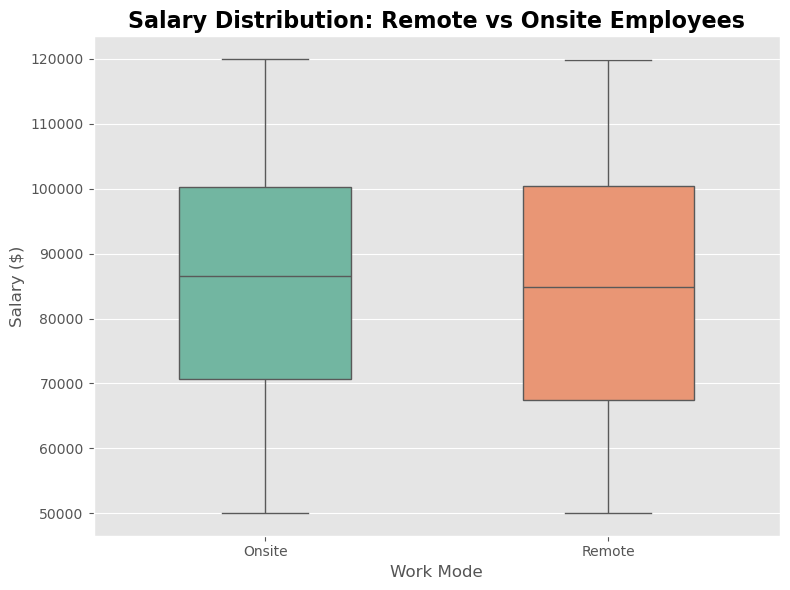

In [205]:
plt.figure(figsize=(8, 6))

ax = sns.boxplot(
    data=df,
    x="remote_work",
    y="salary",
    palette="Set2",
    width=0.5
)

plt.title(
    "Salary Distribution: Remote vs Onsite Employees",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Work Mode", fontsize=12)
plt.ylabel("Salary ($)", fontsize=12)

# Rename x-axis labels
ax.set_xticklabels(["Onsite", "Remote"])

plt.tight_layout()
plt.show()

# Employee Distribution by Department

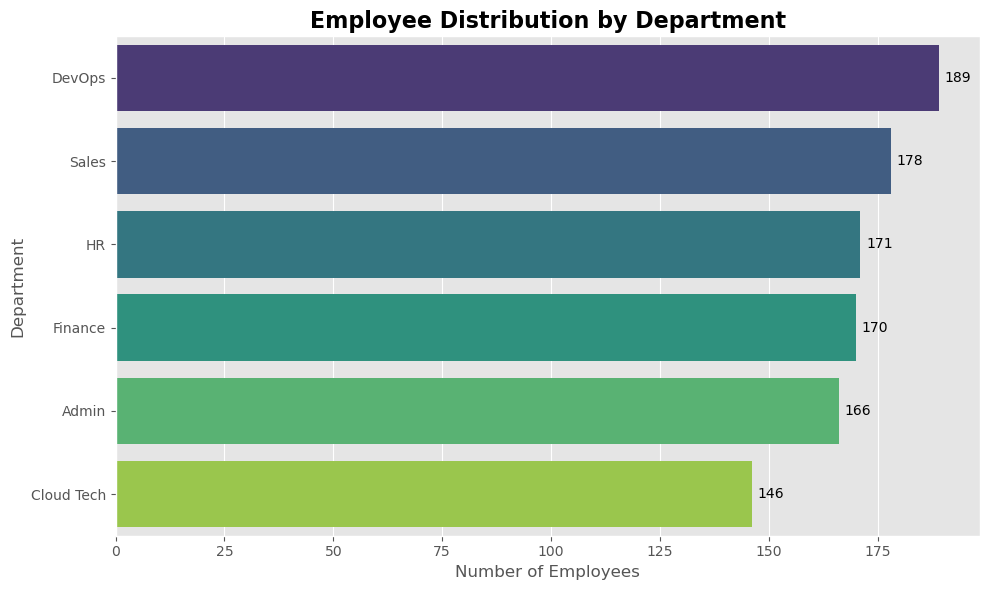

In [206]:
# Count employees in each department
department_count = (
    df.groupby("department")["employee_id"]
      .count()
      .reset_index(name="Employee Count")
      .sort_values(by="Employee Count", ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=department_count,
    x="Employee Count",
    y="department",
    palette="viridis"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=10)

plt.title(
    "Employee Distribution by Department",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Employees", fontsize=12)
plt.ylabel("Department", fontsize=12)

plt.tight_layout()

plt.show()

# Employee Distribution by Region

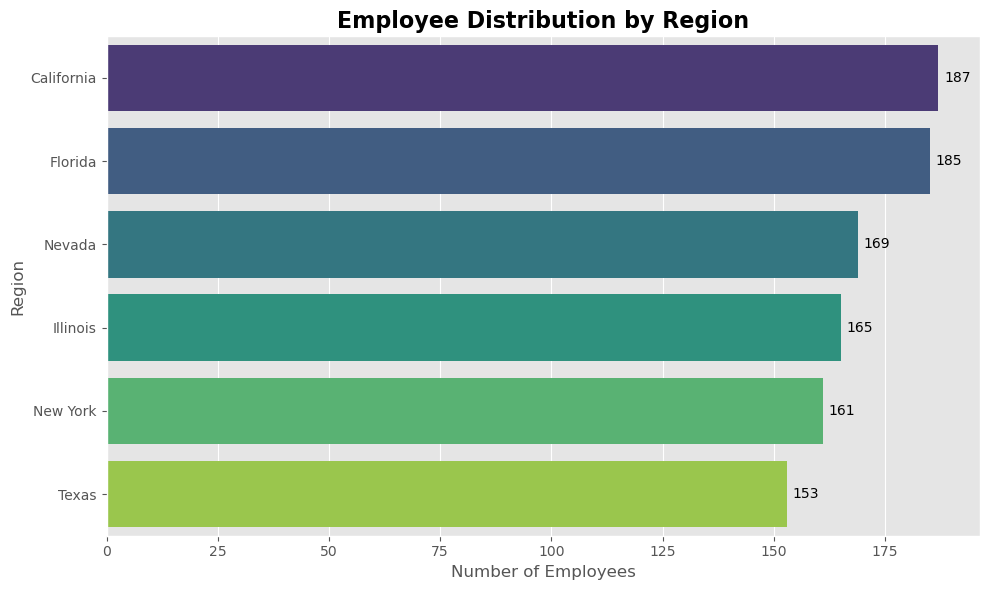

In [207]:
# Count employees in each region
region_count = (
    df.groupby("region")["employee_id"]
      .count()
      .reset_index(name="Employee Count")
      .sort_values(by="Employee Count", ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=region_count,
    x="Employee Count",
    y="region",
    palette="viridis"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=10)

plt.title(
    "Employee Distribution by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Employees", fontsize=12)
plt.ylabel("Region", fontsize=12)

plt.tight_layout()

plt.show()

# Employee Status Analysis

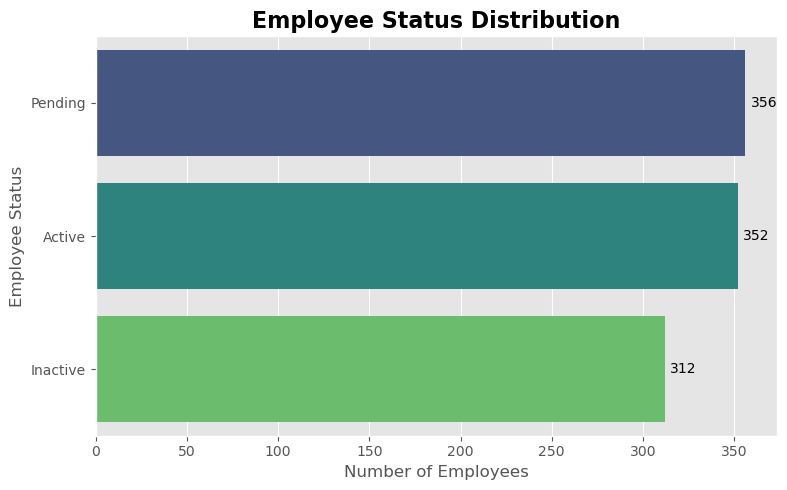

In [208]:
# Count employees by status
status_count = (
    df.groupby("status")["employee_id"]
      .count()
      .reset_index(name="Employee Count")
      .sort_values(by="Employee Count", ascending=False)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=status_count,
    x="Employee Count",
    y="status",
    palette="viridis"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=10)

plt.title(
    "Employee Status Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Employees", fontsize=12)
plt.ylabel("Employee Status", fontsize=12)

plt.tight_layout()

plt.show()

In [209]:
print(df["performance_score"].dtype)
print(df["performance_score"].unique())
print(df["performance_score"].head(10))

int64
[2 4 3 1]
0    2
1    4
2    3
3    3
4    1
5    3
6    3
7    2
8    4
9    4
Name: performance_score, dtype: int64


In [210]:
print(df.columns)

Index(['employee_id', 'employee_name', 'age', 'age_group', 'status',
       'join_date', 'salary', 'performance_score', 'remote_work', 'department',
       'region'],
      dtype='object')


In [211]:
print(
    df.groupby("performance_score")["salary"]
      .agg(["count", "mean"])
)

                   count          mean
performance_score                     
1                    216  85039.935185
2                    267  84280.992509
3                    270  86311.359259
4                    267  85022.625468


In [212]:
df.head()

,employee_id,employee_name,age,age_group,status,join_date,salary,performance_score,remote_work,department,region
0,EMP1000,Bob Davis,25,Young-Adult,Active,4/2/2021,59768,2,True,DevOps,California
1,EMP1001,Bob Brown,30,Young-Adult,Active,7/10/2020,65305,4,True,Finance,Texas
2,EMP1002,Alice Jones,30,Young-Adult,Pending,12/7/2023,88146,3,True,Admin,Nevada
3,EMP1003,Eva Davis,25,Young-Adult,Inactive,11/27/2021,69451,3,True,Admin,Nevada
4,EMP1004,Frank Williams,25,Young-Adult,Active,1/5/2022,109325,1,False,Cloud Tech,Florida


In [213]:
performance_map = {
    1: "Poor",
    2: "Average",
    3: "Good",
    4: "Excellent"
}

df["performance_score"] = df["performance_score"].replace(performance_map)

In [214]:
print(df["performance_score"].unique())

['Average' 'Excellent' 'Good' 'Poor']


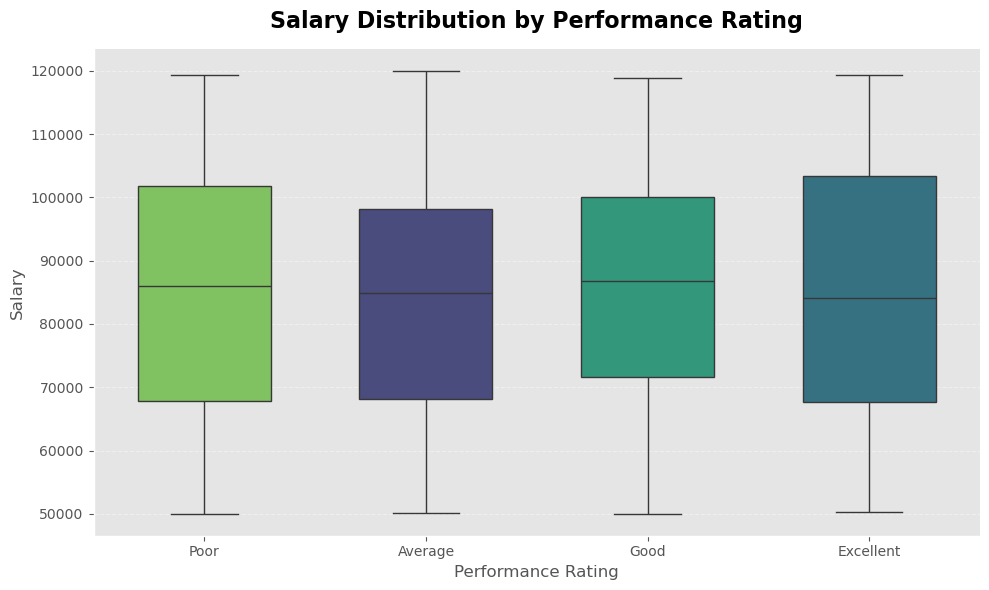

In [215]:
performance_order = ["Poor", "Average", "Good", "Excellent"]

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df,
    x="performance_score",
    y="salary",
    order=performance_order,
    hue="performance_score",
    palette="viridis",
    legend=False,
    width=0.6
)

plt.title(
    "Salary Distribution by Performance Rating",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Performance Rating", fontsize=12)
plt.ylabel("Salary", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

# Performance distribution by Performance scores

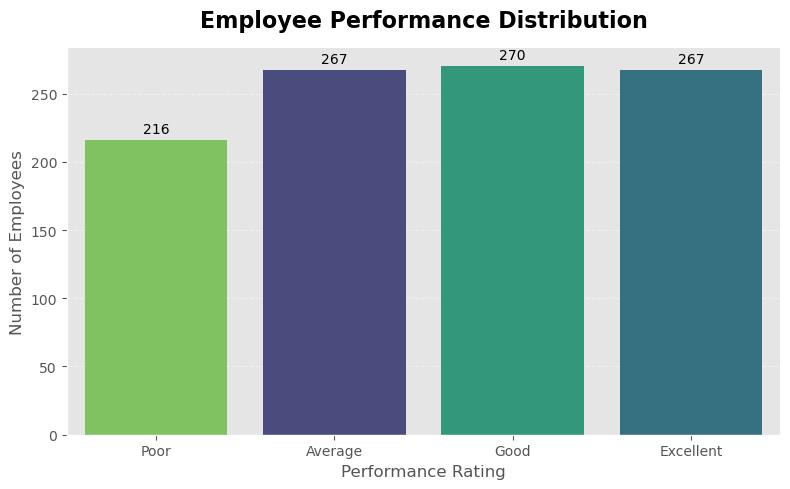

In [216]:
performance_order = ["Poor", "Average", "Good", "Excellent"]

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="performance_score",
    order=performance_order,
    hue="performance_score",
    palette="viridis",
    legend=False
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.title(
    "Employee Performance Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Performance Rating", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()

# Remote work vs Performance

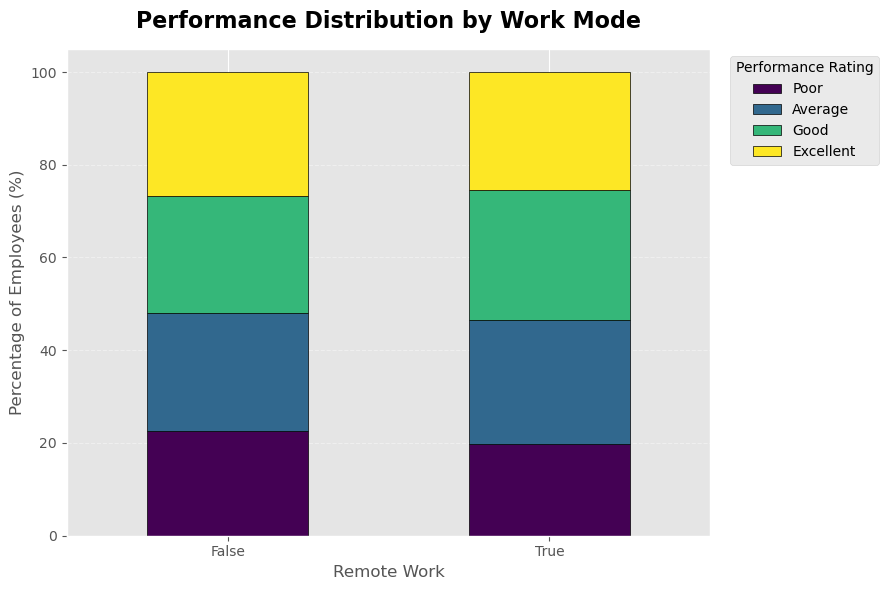

In [217]:
performance_order = ["Poor", "Average", "Good", "Excellent"]

# Create percentage table
performance_remote = (
    pd.crosstab(
        df["remote_work"],
        df["performance_score"],
        normalize="index"
    ) * 100
)

# Reorder columns
performance_remote = performance_remote[performance_order]

# Plot
ax = performance_remote.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6),
    colormap="viridis",
    edgecolor="black"
)

plt.title(
    "Performance Distribution by Work Mode",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Remote Work", fontsize=12)
plt.ylabel("Percentage of Employees (%)", fontsize=12)

plt.xticks(rotation=0)

plt.legend(
    title="Performance Rating",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Hiring Trend over time

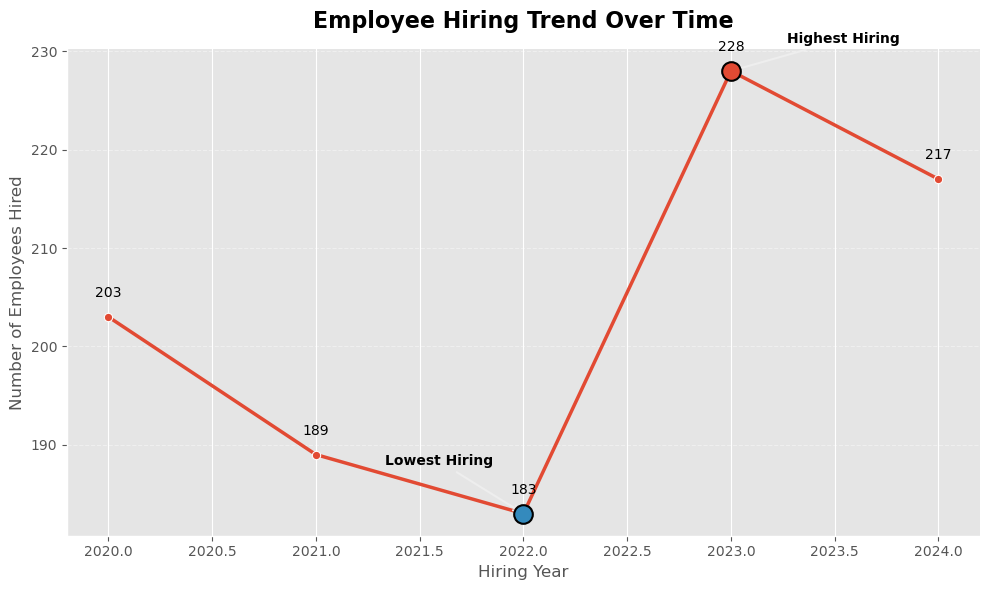

In [218]:
df["join_date"] = pd.to_datetime(df["join_date"])

# Extract year
df["join_year"] = df["join_date"].dt.year

# Count employees hired each year
hiring_trend = (
    df.groupby("join_year")["employee_id"]
      .count()
      .reset_index(name="employees_hired")
)

plt.figure(figsize=(10, 6))

# Line plot
ax = sns.lineplot(
    data=hiring_trend,
    x="join_year",
    y="employees_hired",
    marker="o",
    linewidth=2.5
)

# Add data labels
for x, y in zip(hiring_trend["join_year"], hiring_trend["employees_hired"]):
    plt.text(
        x,
        y + 2,
        str(y),
        ha="center",
        fontsize=10
    )

# Highlight Highest Hiring Year
max_row = hiring_trend.loc[hiring_trend["employees_hired"].idxmax()]

plt.scatter(
    max_row["join_year"],
    max_row["employees_hired"],
    s=180,
    edgecolors="black",
    linewidth=1.5,
    zorder=5
)

plt.annotate(
    "Highest Hiring",
    xy=(max_row["join_year"], max_row["employees_hired"]),
    xytext=(40, 20),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

# Highlight Lowest Hiring Year
min_row = hiring_trend.loc[hiring_trend["employees_hired"].idxmin()]

plt.scatter(
    min_row["join_year"],
    min_row["employees_hired"],
    s=180,
    edgecolors="black",
    linewidth=1.5,
    zorder=5
)

plt.annotate(
    "Lowest Hiring",
    xy=(min_row["join_year"], min_row["employees_hired"]),
    xytext=(-100, 35),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

# Title and labels
plt.title(
    "Employee Hiring Trend Over Time",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Hiring Year", fontsize=12)
plt.ylabel("Number of Employees Hired", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.show()